In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

fred_api = 'add api here'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install fredapi

In [ ]:
from fredapi import Fred

fred = Fred(api_key=fred_api)
brent = fred.get_series('POILBREUSDM', observation_start='1990-01-01')
brent = brent.asfreq('MS')  # monthly start frequency
brent.name = 'Brent_price'
brent.dropna(inplace=True)

## Data 1. Global price of Brent Crude

Units:  U.S. Dollars per Barrel, Not Seasonally Adjusted

In [ ]:
brent

,Brent_price
2003-01-01,30.808696
2003-02-01,32.662500
2003-03-01,30.168095
2003-04-01,25.035000
2003-05-01,25.714545
...,...
2025-09-01,67.609091
2025-10-01,63.981304
2025-11-01,63.693500
2025-12-01,61.810909


## Data 2. Global Crude Oil Production

https://www.eia.gov/international/data/world/petroleum-and-other-liquids/monthly-petroleum-and-other-liquids-production?pd=5&p=0000000000000000000000000000000000vg&u=0&f=M&v=line&a=-&i=none&vo=value&t=C&g=none&l=249--249&s=1036108800000&e=1759276800000

Keep only Crude oil including lease condensate (Mb/d)
- measures actual crude oil production that enters the global oil market.
- includes Conventional crude oil and Condensate from oil fields
- But excludes things that are not directly crude oil supply.

Other variables (Do Not Include):
- Total petroleum and other liquids -	Includes biofuels, synthetic fuels, and other liquids that do not directly determine crude prices
- Crude oil, NGPL, and other liquids -	Adds natural gas liquids and synthetic liquids
- NGPL	- Natural gas liquids behave differently from crude oil
- Other liquids	- Includes ethanol, biodiesel, etc.
- Refinery processing gain -	Not actual production, just volume expansion during refining

In [ ]:
supply = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/global_crudeoil_production.csv")

# Select crude oil production row
crude = supply.iloc[3,1:]   # row 3, skip label column

# Convert to dataframe
crude = crude.to_frame(name="world_crude_supply")

# Convert index (months) to datetime
crude.index = pd.to_datetime(crude.index)

# Sort by date
crude = crude.sort_index()

# Convert to numeric
crude["world_crude_supply"] = pd.to_numeric(crude["world_crude_supply"], errors="coerce")

# Convert to million barrels per day
crude["world_crude_supply"] = crude["world_crude_supply"] / 1000

crude.head()

,world_crude_supply
2002-11-01,67.339771
2002-12-01,66.663530
2003-01-01,69.345818
2003-02-01,70.667015
2003-03-01,70.704776


In [ ]:
merged_df = pd.merge(brent, crude, left_index=True, right_index=True)
merged_df

,Brent_price,world_crude_supply
2003-01-01,30.808696,69.345818
2003-02-01,32.662500,70.667015
2003-03-01,30.168095,70.704776
2003-04-01,25.035000,69.354520
2003-05-01,25.714545,69.169601
...,...,...
2025-06-01,69.846667,84.384482
2025-07-01,69.564783,84.820576
2025-08-01,67.244286,85.290256
2025-09-01,67.609091,86.427981


## Data 3. Kilian Global Real Economic Activity Index (Best demand proxy)

measures Global shipping activity, Global commodity demand

The index uses data on ocean freight rates, which are considered a proxy for global demand for raw materials, especially during economic expansions or contractions.

Units:

Index,
Not Seasonally Adjusted

In [ ]:
# pull the series
igrea = fred.get_series("IGREA")

# convert to dataframe
igrea = igrea.to_frame(name="global_demand_proxy")

# ensure datetime index
igrea.index = pd.to_datetime(igrea.index)

igrea.head()

,global_demand_proxy
1968-01-01,-12.803711
1968-02-01,-9.480319
1968-03-01,-11.314132
1968-04-01,-11.437653
1968-05-01,-10.701954


Aligned and merged 3 datasets into one time series dataframe, spans from 2003-01-01	to 2025-10-01.

In [ ]:
# Final dataframe to be used for modeling
final_df = pd.merge(merged_df, igrea, left_index=True, right_index=True)
final_df

,Brent_price,world_crude_supply,global_demand_proxy
2003-01-01,30.808696,69.345818,9.638756
2003-02-01,32.662500,70.667015,8.072543
2003-03-01,30.168095,70.704776,18.073845
2003-04-01,25.035000,69.354520,29.568834
2003-05-01,25.714545,69.169601,37.680731
...,...,...,...
2025-06-01,69.846667,84.384482,-2.320013
2025-07-01,69.564783,84.820576,5.244006
2025-08-01,67.244286,85.290256,14.515912
2025-09-01,67.609091,86.427981,20.388900


In [ ]:
#final_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/final_df.csv")

## EDA

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 274 entries, 2003-01-01 to 2025-10-01
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brent_price          274 non-null    float64
 1   world_crude_supply   274 non-null    float64
 2   global_demand_proxy  274 non-null    float64
dtypes: float64(3)
memory usage: 8.6 KB


The dataset contains 274 monthly observations for Brent crude prices, world crude oil supply, and the global demand proxy.

**Brent Crude Oil Price**
- Mean: 72.38 per barrel
- Standard deviation: 25.38
- Minimum: 25.04
- Maximum: 133.59

This indicates substantial price volatility over the sample period. The minimum price corresponds to periods of weak global demand or market disruptions, while the maximum reflects major oil price spikes. The large standard deviation relative to the mean suggests Brent prices fluctuate significantly in response to economic conditions and supply shocks.

**World Crude Oil Supply**
- Mean: 77.58 million barrels per day
- Standard deviation: 4.05
- Minimum: 68.98 Mb/d
- Maximum: 86.43 Mb/d

Global crude oil production shows much lower variability compared to prices, reflecting the relatively gradual adjustments in global production capacity. The range indicates a steady increase in global oil supply over the sample period.

**Global Demand Proxy (Kilian Index)**
- Mean: 11.24
- Standard deviation: 70.35
- Minimum: −161.10
- Maximum: 189.59

The global economic activity index exhibits large fluctuations, capturing changes in worldwide economic conditions and commodity demand. The wide range reflects strong expansions and contractions in global economic activity, which are key drivers of oil demand.

Overall:
- Oil prices are far more volatile than supply, reflecting market shocks and expectations.
- Global crude production changes gradually, consistent with investment and production constraints in the oil industry.
- The global demand proxy shows strong cyclical variation, capturing economic expansions and recessions that influence oil demand.

In [ ]:
final_df.describe()

,Brent_price,world_crude_supply,global_demand_proxy
count,274.000000,274.000000,274.000000
mean,72.376248,77.579856,11.241240
std,25.378193,4.049878,70.345211
min,25.035000,68.983813,-161.096880
25%,54.587055,74.216479,-39.196539
50%,70.449565,76.859697,5.886224
75%,88.967841,81.569360,54.675382
max,133.585217,86.427981,189.586420


No NAs observed.

In [ ]:
final_df.isna().sum()

,0
Brent_price,0
world_crude_supply,0
global_demand_proxy,0


Visual inspection of the three time series—Brent Crude Oil Price ($/barrel), World Crude Oil Supply (Mb/d), and the Global Economic Activity Index—suggests that the mean of the series changes over time, while the variance appears relatively stable. Notable volatility spikes occur during periods of global economic stress, such as the 2008 financial crisis. These patterns indicate that the series likely exhibit non-stationary behavior, particularly due to trends or structural changes in their mean levels. Therefore, formal stationarity tests ADF and KPSS are required to confirm whether the variables contain unit roots before proceeding with time-series modeling.

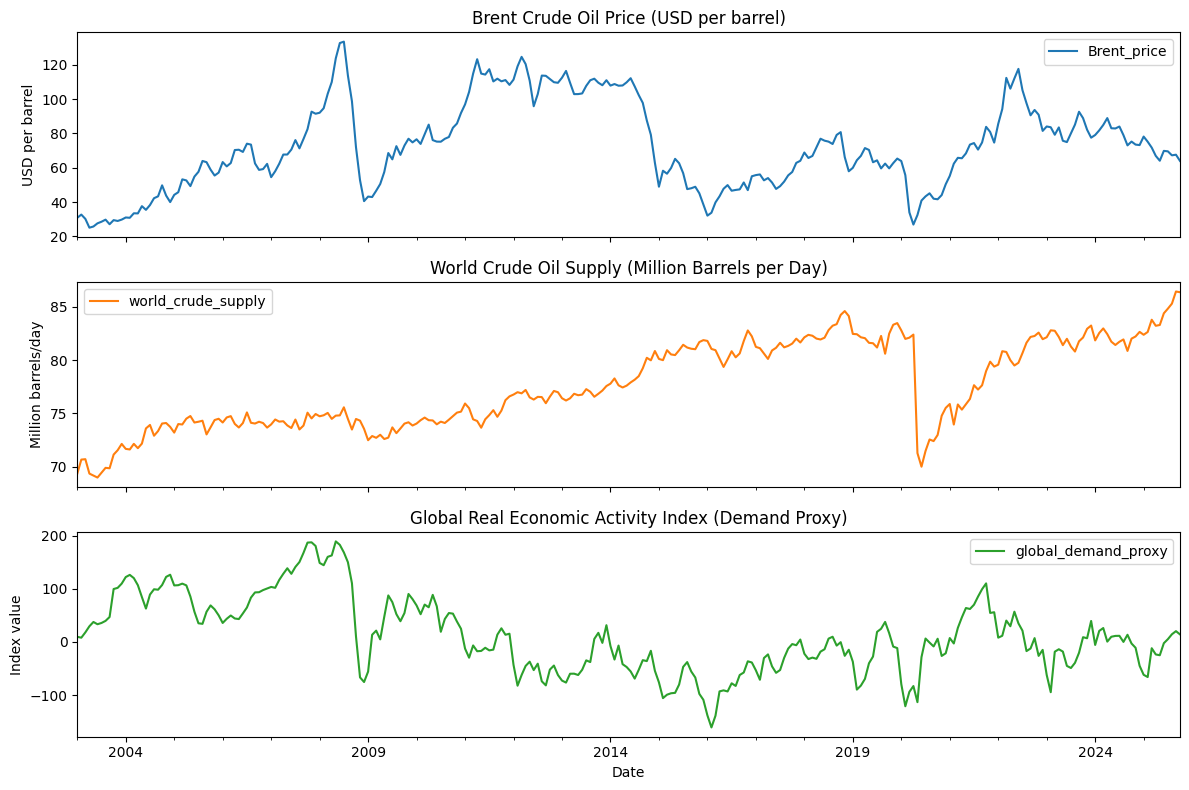

In [ ]:
import matplotlib.pyplot as plt

axes = final_df.plot(
    subplots=True,
    figsize=(12,8),
    title=[
        "Brent Crude Oil Price (USD per barrel)",
        "World Crude Oil Supply (Million Barrels per Day)",
        "Global Real Economic Activity Index (Demand Proxy)"
    ]
)

axes[0].set_ylabel("USD per barrel")
axes[1].set_ylabel("Million barrels/day")
axes[2].set_ylabel("Index value")

for ax in axes:
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

The Brent Crude Oil Price ($/barrel) series shows an overall upward trend over the sample period, with episodes of sharp increases and declines, suggesting periods of mean reversion following large price shocks. The World Crude Oil Supply (Mb/d) series also exhibits a gradual upward trend, reflecting long-term growth in global production capacity, with a noticeable decline in 2020 corresponding to the global economic disruption caused by the COVID-19 pandemic. In contrast, the Global Economic Activity Index, which serves as a proxy for global oil demand, does not display a clear long-term trend but instead fluctuates cyclically around its mean, reflecting expansions and contractions in global economic activity.

Visually, the three series appear to co-move over time, particularly during periods of economic stress or recovery. For example, declines in the global economic activity index tend to coincide with decreases in oil prices and adjustments in supply, suggesting that global economic conditions play an important role in influencing both oil demand and market prices.

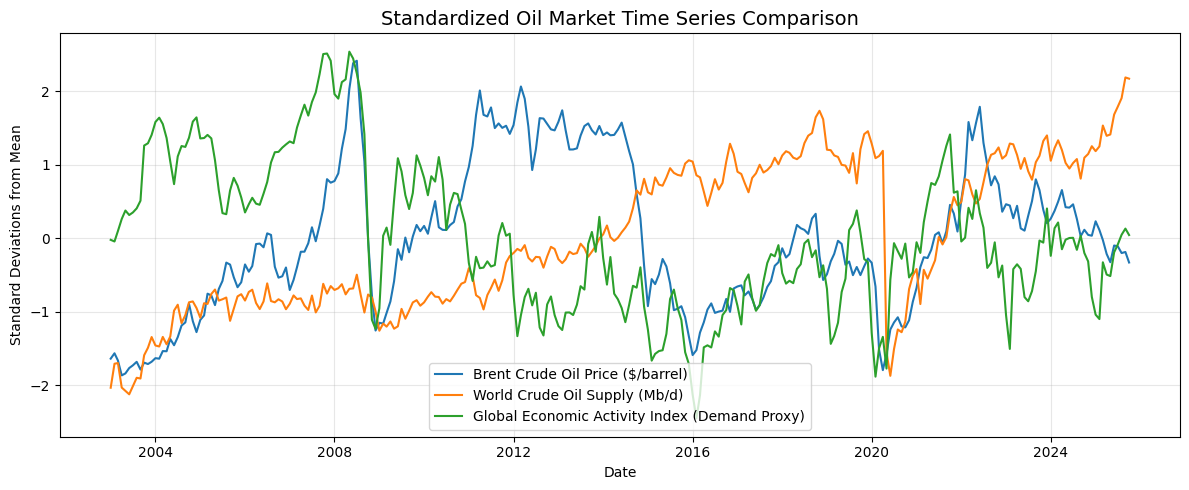

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- Standardized Series for Comparison ---
df_standardized = final_df[['Brent_price', 'world_crude_supply', 'global_demand_proxy']].copy()

for col in df_standardized.columns:
    df_standardized[col] = (df_standardized[col] - df_standardized[col].mean()) / df_standardized[col].std()

plt.figure(figsize=(12,5))

plt.plot(final_df.index,
         df_standardized['Brent_price'],
         label='Brent Crude Oil Price ($/barrel)',
         linewidth=1.5)

plt.plot(final_df.index,
         df_standardized['world_crude_supply'],
         label='World Crude Oil Supply (Mb/d)',
         linewidth=1.5)

plt.plot(final_df.index,
         df_standardized['global_demand_proxy'],
         label='Global Economic Activity Index (Demand Proxy)',
         linewidth=1.5)

plt.title('Standardized Oil Market Time Series Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

After standardizing the three series we observe periods of co-movement, particularly during episodes of global economic stress or recovery. For example, declines in the economic activity index often coincide with decreases in oil prices and adjustments in supply. However, the relationship is not always consistent. During 2010–2014, Brent prices and global supply increased while the economic activity index weakened. Conversely, during 2014–2016, global supply continued to rise while Brent prices and the economic activity index declined, reflecting the global oil supply glut and subsequent price collapse. Among the three variables, world crude oil supply appears to be the most stable, exhibiting gradual changes over time compared with the more volatile movements in oil prices and the cyclical fluctuations of the economic activity index.

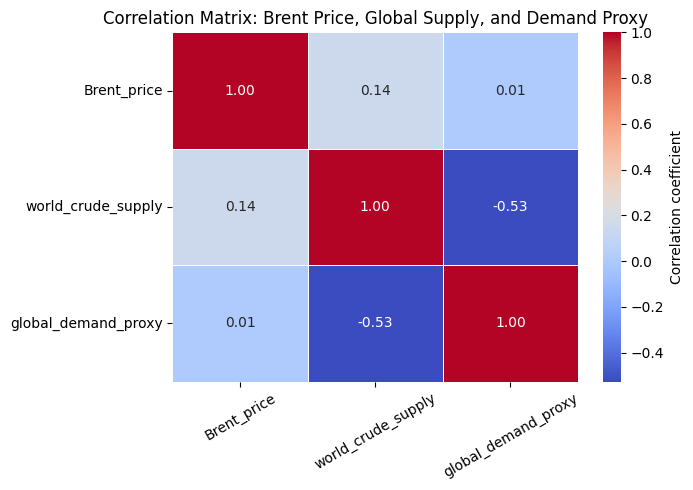

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,5))

corr_matrix = final_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation Matrix: Brent Price, Global Supply, and Demand Proxy", fontsize=12)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The correlation matrix indicates weak contemporaneous relationships between Brent crude prices and both global oil supply and the global demand proxy. This is consistent with oil market dynamics, where prices respond to supply and demand shocks with lags. The strongest relationship is a moderate negative correlation between global supply and the demand proxy, suggesting adjustments in production relative to global economic activity.

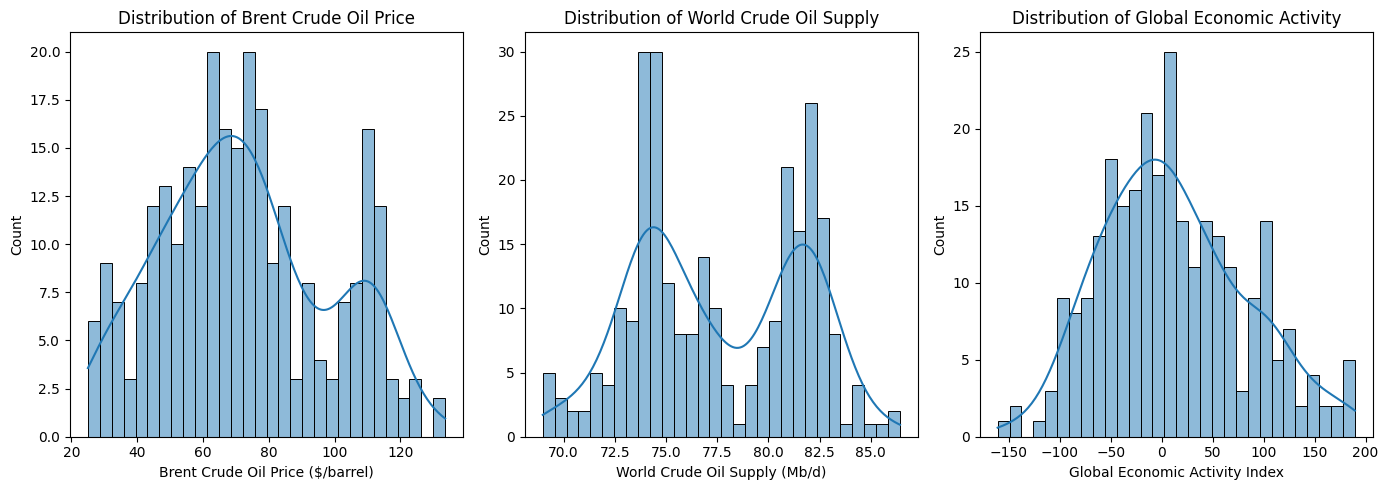

In [ ]:
# Rename columns for clearer labels
df_plot = final_df.rename(columns={
    "Brent_price": "Brent Crude Oil Price ($/barrel)",
    "world_crude_supply": "World Crude Oil Supply (Mb/d)",
    "global_demand_proxy": "Global Economic Activity Index"
})

fig, axes = plt.subplots(1, 3, figsize=(14,5))

sns.histplot(df_plot["Brent Crude Oil Price ($/barrel)"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Brent Crude Oil Price")

sns.histplot(df_plot["World Crude Oil Supply (Mb/d)"], kde=True, bins=30, ax=axes[1])
axes[1].set_title("Distribution of World Crude Oil Supply")

sns.histplot(df_plot["Global Economic Activity Index"], kde=True, bins=30, ax=axes[2])
axes[2].set_title("Distribution of Global Economic Activity")

plt.tight_layout()
plt.show()

The histograms provide additional evidence of non-stationary behavior in the variables. The distribution of Brent Crude Oil Price (dollars/barrel) shows concentrations around approximately 60–80 and another cluster near 110, suggesting that the mean price level changes over time across different market regimes. Similarly, the histogram for World Crude Oil Supply (Mb/d) shows concentrations around roughly 74–75 Mb/d and 82 Mb/d, indicating shifts in the average level of global production over the sample period. In contrast, the Global Economic Activity Index appears to be centered around −25 to 0, with a long right tail reflecting periods of strong global economic expansion. The presence of multiple clusters and skewness in the distributions suggests that the series may experience structural changes or regime shifts over time, further supporting the need to formally test for stationarity before proceeding with time-series modeling.

Percent Change of the 3 Series:

In [ ]:
df_growth = final_df.pct_change()
df_growth.describe()

,Brent_price,world_crude_supply,global_demand_proxy
count,273.000000,273.000000,273.000000
mean,0.006540,0.000875,0.719971
std,0.085799,0.011656,10.385701
min,-0.390435,-0.134895,-19.254245
25%,-0.044844,-0.004526,-0.316073
50%,0.013608,0.002024,-0.020992
75%,0.066607,0.006211,0.257360
max,0.260255,0.025477,156.042773


**Brent Crude Oil Price**

The mean monthly change in Brent prices is approximately 0.65%, with a relatively large standard deviation of 8.58%, indicating substantial price volatility. The minimum monthly change of −39% and maximum change of 26% highlight the large swings that can occur in oil markets during periods of economic shocks or geopolitical events.

**World Crude Oil Supply**

The mean monthly growth in global crude oil supply is approximately 0.09%, with a much smaller standard deviation of 1.17%. This reflects the relatively gradual adjustments in global oil production compared with the much more volatile movements in oil prices. Supply changes tend to occur slowly due to investment constraints and production capacity limitations.

**Global Economic Activity Index**

The demand proxy exhibits a mean monthly change of 0.72, but with a very large standard deviation of 10.39, reflecting substantial fluctuations in global economic conditions. The wide range of values indicates periods of both strong economic expansion and contraction.

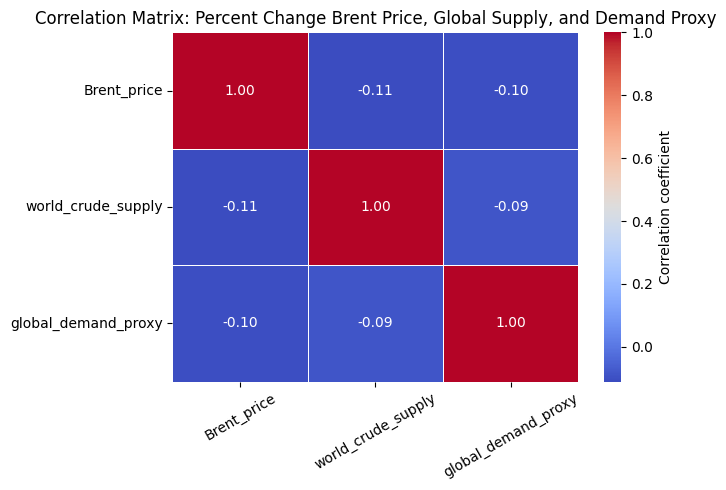

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df_growth.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation Matrix: Percent Change Brent Price, Global Supply, and Demand Proxy", fontsize=12)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Weak negative relationships across variables suggest that short-term changes in oil prices, supply, and global economic activity are not strongly synchronized contemporaneously. This is consistent with oil market dynamics, where adjustments in supply and demand often occur with lags rather than simultaneously. As a result, contemporaneous correlations may appear weak even though dynamic relationships exist over time.

## Train, Test split (Last 24 months as Test set)

Train set:  2003-01-01 to 2023-10-01

Test set: 2023-11-01 to 2025-10-01


In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
from sktime.forecasting.all import temporal_train_test_split

train_df, test_df = temporal_train_test_split(final_df, test_size=24)

In [ ]:
# Define ADF and KPSS test function
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(series, name="Series", alpha=0.05, regression="c"):

    s = series.dropna()

    print(f"\n===== {name} =====")

    # -------- ADF --------
    adf_stat, adf_p, _, _, _, _ = adfuller(s, regression=regression, autolag='AIC')

    print("\nADF Test (H0: Non-Stationary)")
    print(f"Test Statistic: {adf_stat:.4f}")
    print(f"P-value: {adf_p:.4f}")

    if adf_p < alpha:
        print("Reject H0: Likely Stationary")
    else:
        print("Fail to Reject H0: Likely Non-Stationary")


    # -------- KPSS --------
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")

    print("\nKPSS Test (H0: Stationary)")
    print(f"Test Statistic: {kpss_stat:.4f}")
    print(f"P-value: {kpss_p:.4f}")

    if kpss_p < alpha:
        print("Reject H0: Likely Non-Stationary")
    else:
        print("Fail to Reject H0: Likely Stationary")


    # -------- Combined Conclusion --------
    print("\nOverall Interpretation:")

    if adf_p < alpha and kpss_p >= alpha:
        print("Strong evidence of stationarity")
    elif adf_p >= alpha and kpss_p < alpha:
        print("Strong evidence of non-stationarity")
    else:
        print("Mixed results — consider differencing or adding trend")

In [ ]:
# Define acf and pacf function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(series, lags=40, title="Series"):

    s = series.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_acf(s, lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF - {title}")

    plot_pacf(s, lags=lags, ax=axes[1], method='ywm')
    axes[1].set_title(f"PACF - {title}")

    plt.tight_layout()
    plt.show()

In [ ]:
check_stationarity(train_df['Brent_price'])


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -2.8907
P-value: 0.0464
Reject H0: Likely Stationary

KPSS Test (H0: Stationary)
Test Statistic: 0.2962
P-value: 0.1000
Fail to Reject H0: Likely Stationary

Overall Interpretation:
Strong evidence of stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


In [ ]:
check_stationarity(train_df['world_crude_supply'])


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -1.9271
P-value: 0.3194
Fail to Reject H0: Likely Non-Stationary

KPSS Test (H0: Stationary)
Test Statistic: 1.7084
P-value: 0.0100
Reject H0: Likely Non-Stationary

Overall Interpretation:
Strong evidence of non-stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


In [ ]:
check_stationarity(train_df['global_demand_proxy'])


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -2.0316
P-value: 0.2729
Fail to Reject H0: Likely Non-Stationary

KPSS Test (H0: Stationary)
Test Statistic: 1.1196
P-value: 0.0100
Reject H0: Likely Non-Stationary

Overall Interpretation:
Strong evidence of non-stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


ADF and KPSS tests show Brent price as stationary, World Crude oil supply as non-stationary, and Economic index as non stationary.

**Brent Price:**
- ADF p = 0.046
- KPSS p = 0.10
- These are borderline results. And prior visual inspection suggested non-stationarity.
- ADF barely rejects non-stationarity while KPSS barely accepts stationarity. - This is common when:
    - there are structural breaks (oil crises, COVID, wars)
    - sample size is limited
    - volatility shifts exist

Hence, we will difference Brent Price, Crude supply, Global demand and check stationarity again.


In [ ]:
check_stationarity(train_df['Brent_price'].diff(1))


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -10.6838
P-value: 0.0000
Reject H0: Likely Stationary

KPSS Test (H0: Stationary)
Test Statistic: 0.0629
P-value: 0.1000
Fail to Reject H0: Likely Stationary

Overall Interpretation:
Strong evidence of stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


In [ ]:
check_stationarity(train_df['world_crude_supply'].diff(1))


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -6.3105
P-value: 0.0000
Reject H0: Likely Stationary

KPSS Test (H0: Stationary)
Test Statistic: 0.0433
P-value: 0.1000
Fail to Reject H0: Likely Stationary

Overall Interpretation:
Strong evidence of stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


In [ ]:
check_stationarity(train_df['global_demand_proxy'].diff(1))


===== Series =====

ADF Test (H0: Non-Stationary)
Test Statistic: -6.3676
P-value: 0.0000
Reject H0: Likely Stationary

KPSS Test (H0: Stationary)
Test Statistic: 0.0385
P-value: 0.1000
Fail to Reject H0: Likely Stationary

Overall Interpretation:
Strong evidence of stationarity


/tmp/ipykernel_228/172060462.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")


After 1st differencing, all 3 series are stationary based on ADF and KPSS tests.

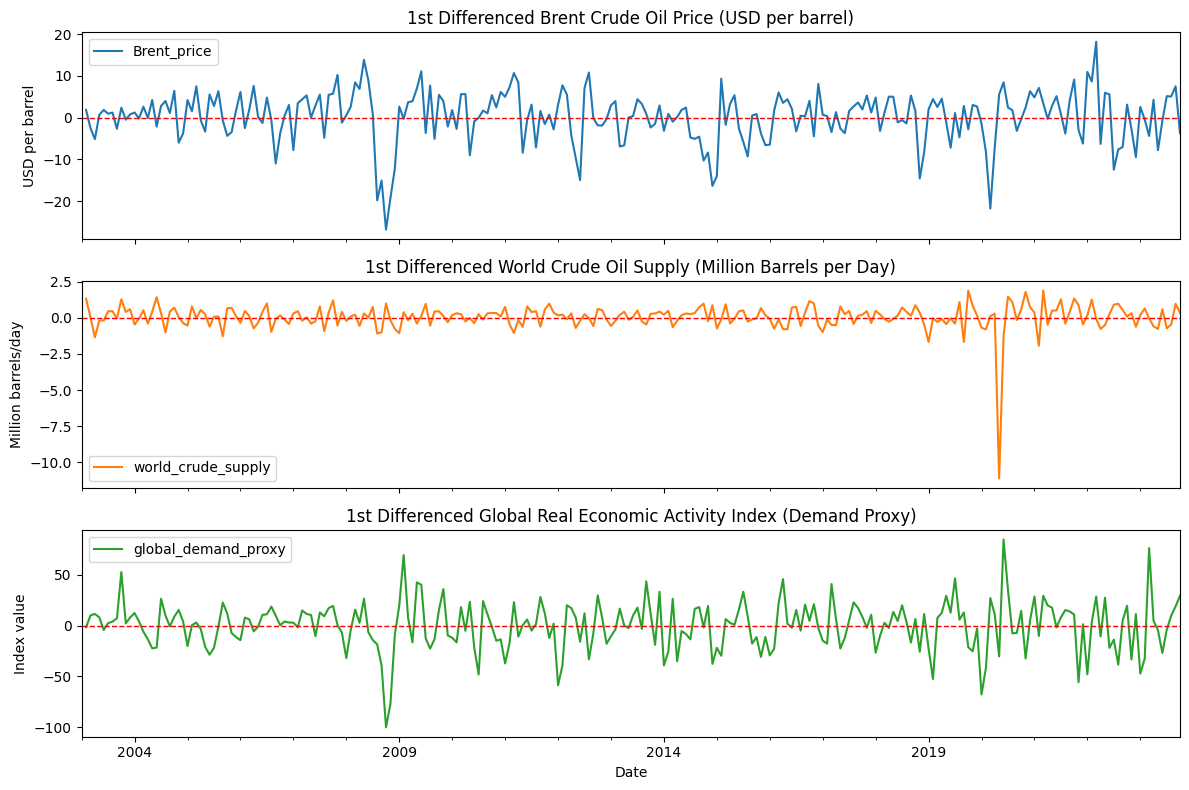

In [ ]:
axes = train_df.diff(1).plot(
    subplots=True,
    figsize=(12,8),
    title=[
        "1st Differenced Brent Crude Oil Price (USD per barrel)",
        "1st Differenced World Crude Oil Supply (Million Barrels per Day)",
        "1st Differenced Global Real Economic Activity Index (Demand Proxy)"
    ]
)

axes[0].set_ylabel("USD per barrel")
axes[1].set_ylabel("Million barrels/day")
axes[2].set_ylabel("Index value")

for ax in axes:
    ax.set_xlabel("Date")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)


plt.tight_layout()
plt.show()

**ACF and PACF plots before differencing:**

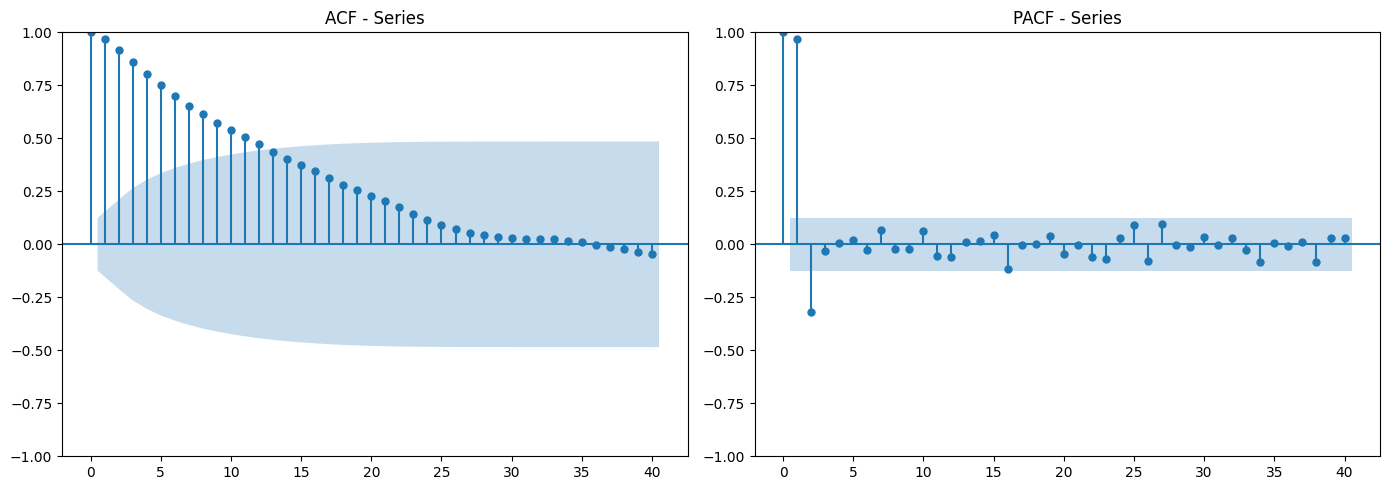

In [ ]:
plot_acf_pacf(train_df['Brent_price'])

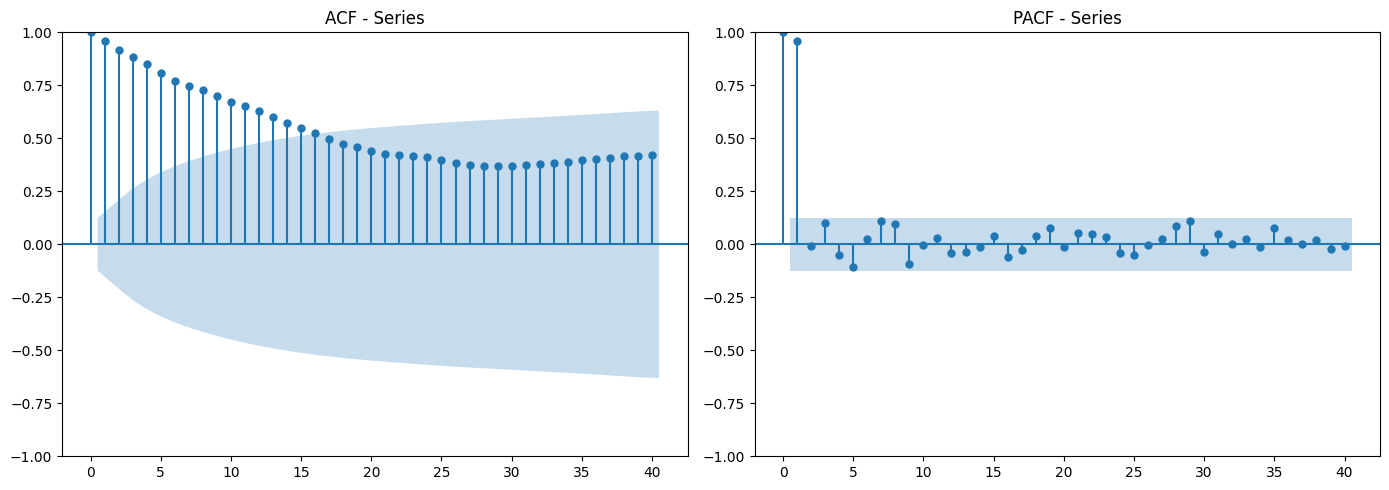

In [ ]:
plot_acf_pacf(train_df['world_crude_supply'])

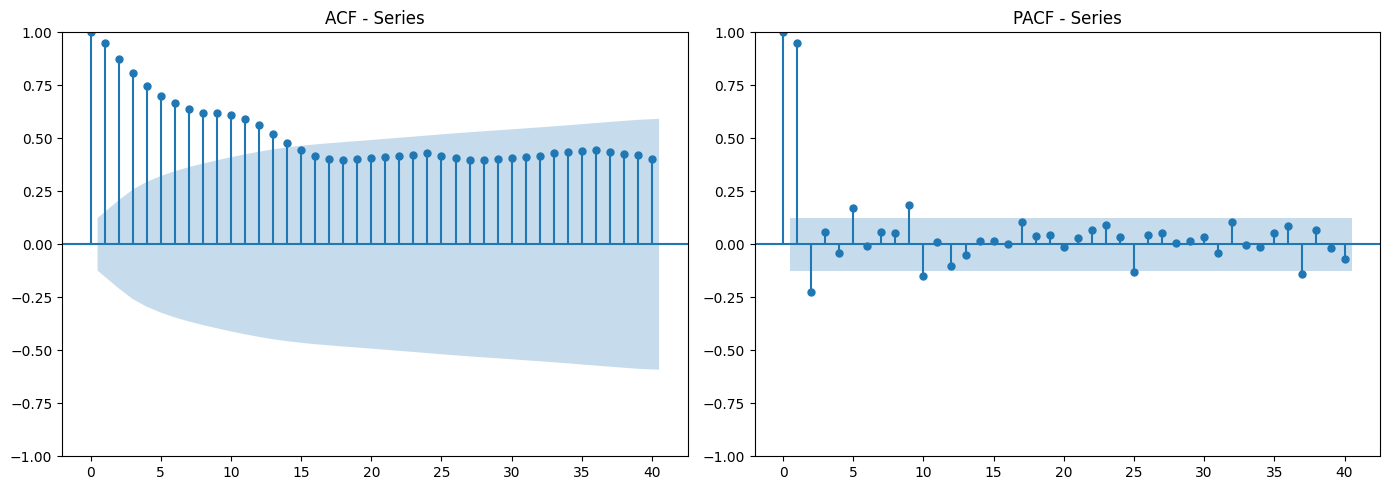

In [ ]:
plot_acf_pacf(train_df['global_demand_proxy'])

**ACF and PACF plots after differencing:**

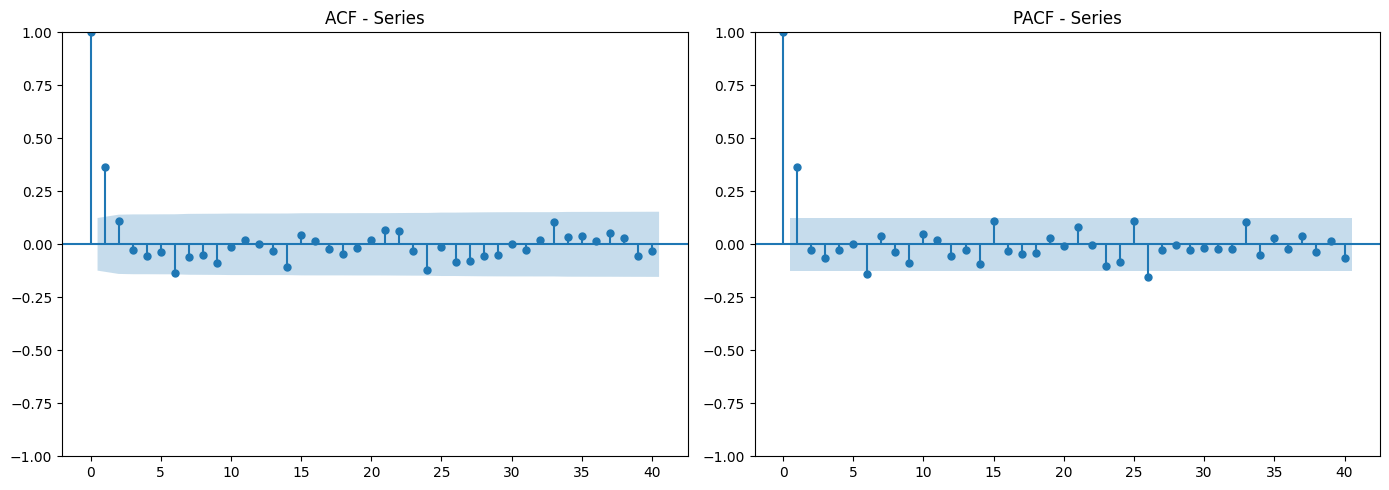

In [ ]:
plot_acf_pacf(train_df['Brent_price'].diff(1))

ACF and PACF of Differenced Brent Price:
- ACF: Significant lags at lag 1
- PACF: Significant lag at lag 1, 6 (half year) and 26

Suggests an AR(1, 1, 0) initial model specification for Brent price. No seasonality observed hence we will not need a SARIMA model.

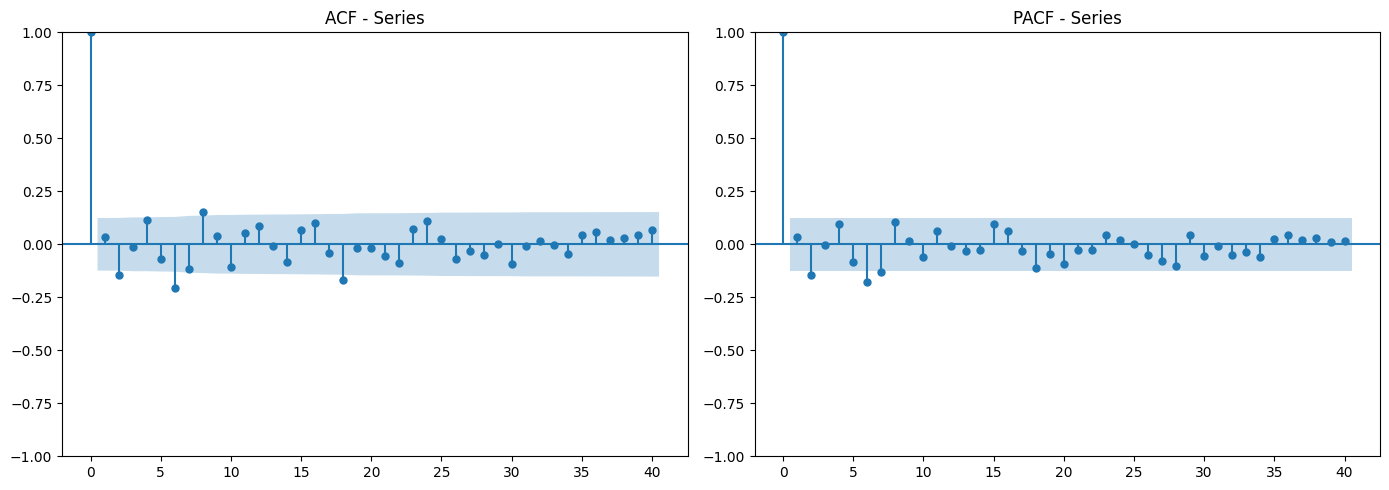

In [ ]:
plot_acf_pacf(train_df['world_crude_supply'].diff(1))

ACF and PACF of Differenced World Crude supply:
- ACF: Significant lags at lag 2, 6, 8, 18
- PACF: Significant lags at 2, 6 (half year), 7

The ACF of the first-differenced world crude oil supply suggests persistence and cyclical dynamics in production adjustments. The PACF shows significant spikes at lags 2, 6, and 7, indicating short-run autoregressive behavior and possible semiannual adjustment cycles. These patterns reflect the gradual and coordinated nature of global oil supply responses to market conditions.

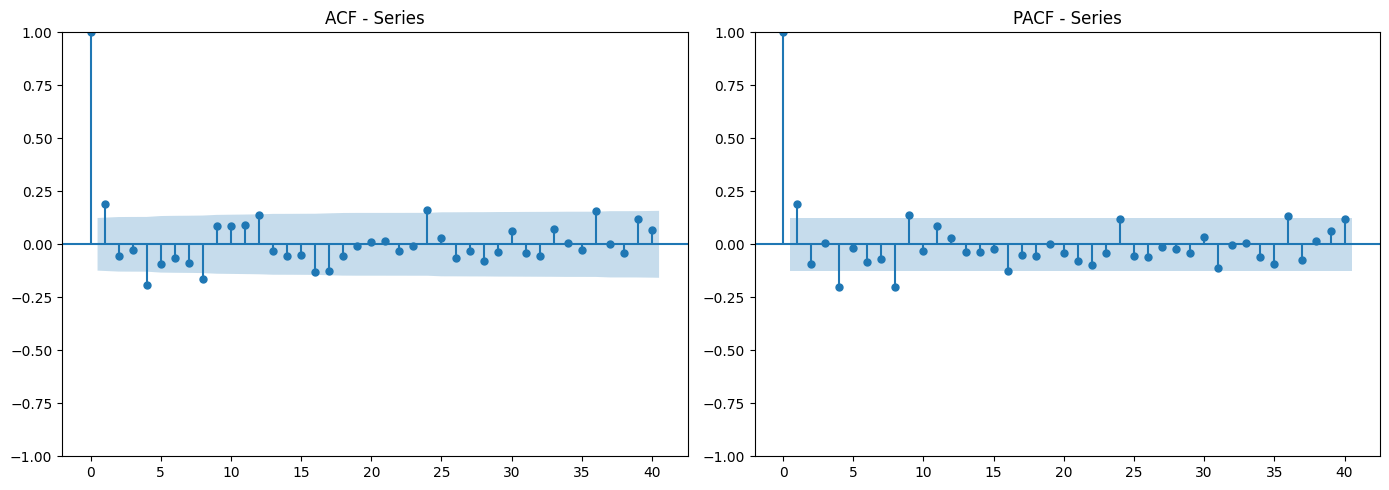

In [ ]:
plot_acf_pacf(train_df['global_demand_proxy'].diff(1))

ACF and PACF of Differenced Global demand proxy:
- ACF: Significant lags at lag 1, 4, 8, 24
- PACF: Significant lags at 1, 4, 8, 16

The ACF of the differenced global demand proxy shows significant spikes at lags 1, 4, 8, and 24, indicating both short-term persistence and longer cyclical dynamics in global economic activity. The PACF shows significant spikes at lags 1, 4, 8, and 16, suggesting that demand adjustments occur over multiple months rather than instantaneously. These patterns are consistent with business-cycle fluctuations and gradual adjustments in global economic activity.